# Phase 3: Model Development & Training

## Overview
This notebook covers:
- Train/test split of preprocessed data
- Model selection and training
- Hyperparameter tuning
- Performance evaluation with appropriate metrics

## Models to Train
1. **Logistic Regression** (baseline)
2. **Random Forest** (ensemble)
3. **Gradient Boosting** (advanced)

## Evaluation Metrics
- ROC-AUC Score (primary - handles imbalance well)
- F1 Score
- Precision and Recall
- Confusion Matrix

## Class Imbalance Handling
- Use SMOTE on training data (done in Phase 2)
- Add class weights to models
- Use stratified cross-validation

In [1]:
# Imports and setup
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import roc_auc_score, f1_score, confusion_matrix, classification_report
import sys
sys.path.append('../src')
from train import prepare_data, apply_smote, train_model, evaluate_model

print("Phase 3: Model Training & Evaluation")

Phase 3: Model Training & Evaluation


In [1]:
# Load preprocessed data
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, roc_curve, f1_score, 
    precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report
)
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Phase 3: Model Training and Evaluation\n")

# Load preprocessed data
X_train = pd.read_csv('../data/preprocessed/X_train.csv')
y_train = pd.read_csv('../data/preprocessed/y_train.csv').values.ravel()
X_val = pd.read_csv('../data/preprocessed/X_val.csv')
y_val = pd.read_csv('../data/preprocessed/y_val.csv').values.ravel()
X_test = pd.read_csv('../data/preprocessed/X_test.csv')
y_test = pd.read_csv('../data/preprocessed/y_test.csv').values.ravel()

print(f"Training set: {X_train.shape}")
print(f"Validation set: {X_val.shape}")
print(f"Test set: {X_test.shape}")
print(f"Feature count: {X_train.shape[1]}")

Phase 3: Model Training and Evaluation

Training set: (91314, 2343)
Validation set: (10728, 2343)
Test set: (10728, 2343)
Feature count: 2343


In [3]:
# Model 1: Logistic Regression (Baseline + Interpretable)
print("\n" + "="*60)
print("MODEL 1: Logistic Regression")
print("="*60)
print("Why: Baseline model + highly interpretable for clinicians")

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

print("\nTraining Logistic Regression...")
lr_model.fit(X_train, y_train)

# Predictions
lr_val_pred = lr_model.predict(X_val)
lr_val_proba = lr_model.predict_proba(X_val)[:, 1]
lr_test_pred = lr_model.predict(X_test)
lr_test_proba = lr_model.predict_proba(X_test)[:, 1]

# Validation metrics
lr_val_auc = roc_auc_score(y_val, lr_val_proba)
lr_val_f1 = f1_score(y_val, lr_val_pred)
lr_val_ap = average_precision_score(y_val, lr_val_proba)

# Test metrics
lr_test_auc = roc_auc_score(y_test, lr_test_proba)
lr_test_f1 = f1_score(y_test, lr_test_pred)
lr_test_ap = average_precision_score(y_test, lr_test_proba)

print(f"\nValidation Metrics:")
print(f"  AUC-ROC: {lr_val_auc:.4f}")
print(f"  F1-Score: {lr_val_f1:.4f}")
print(f"  Avg Precision: {lr_val_ap:.4f}")

print(f"\nTest Metrics:")
print(f"  AUC-ROC: {lr_test_auc:.4f}")
print(f"  F1-Score: {lr_test_f1:.4f}")
print(f"  Avg Precision: {lr_test_ap:.4f}")
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, lr_test_pred, target_names=['No Readmission', 'Readmission']))


MODEL 1: Logistic Regression
Why: Baseline model + highly interpretable for clinicians

Training Logistic Regression...

Validation Metrics:
  AUC-ROC: 0.6198
  F1-Score: 0.2082
  Avg Precision: 0.1455

Test Metrics:
  AUC-ROC: 0.6270
  F1-Score: 0.2167
  Avg Precision: 0.1443

Classification Report (Test Set):
                precision    recall  f1-score   support

No Readmission       0.94      0.69      0.80      9784
   Readmission       0.14      0.51      0.22       944

      accuracy                           0.68     10728
     macro avg       0.54      0.60      0.51     10728
  weighted avg       0.87      0.68      0.75     10728



In [4]:
# Model 2: Random Forest (Strong Ensemble)
print("\n" + "="*60)
print("MODEL 2: Random Forest")
print("="*60)
print("Why: Strong ensemble method, handles non-linearity well")

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42,
    class_weight='balanced',
    n_jobs=-1
)

print("\nTraining Random Forest...")
rf_model.fit(X_train, y_train)

# Predictions
rf_val_pred = rf_model.predict(X_val)
rf_val_proba = rf_model.predict_proba(X_val)[:, 1]
rf_test_pred = rf_model.predict(X_test)
rf_test_proba = rf_model.predict_proba(X_test)[:, 1]

# Validation metrics
rf_val_auc = roc_auc_score(y_val, rf_val_proba)
rf_val_f1 = f1_score(y_val, rf_val_pred)
rf_val_ap = average_precision_score(y_val, rf_val_proba)

# Test metrics
rf_test_auc = roc_auc_score(y_test, rf_test_proba)
rf_test_f1 = f1_score(y_test, rf_test_pred)
rf_test_ap = average_precision_score(y_test, rf_test_proba)

print(f"\nValidation Metrics:")
print(f"  AUC-ROC: {rf_val_auc:.4f}")
print(f"  F1-Score: {rf_val_f1:.4f}")
print(f"  Avg Precision: {rf_val_ap:.4f}")

print(f"\nTest Metrics:")
print(f"  AUC-ROC: {rf_test_auc:.4f}")
print(f"  F1-Score: {rf_test_f1:.4f}")
print(f"  Avg Precision: {rf_test_ap:.4f}")
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, rf_test_pred, target_names=['No Readmission', 'Readmission']))


MODEL 2: Random Forest
Why: Strong ensemble method, handles non-linearity well

Training Random Forest...

Validation Metrics:
  AUC-ROC: 0.6458
  F1-Score: 0.0553
  Avg Precision: 0.1658

Test Metrics:
  AUC-ROC: 0.6319
  F1-Score: 0.0358
  Avg Precision: 0.1502

Classification Report (Test Set):
                precision    recall  f1-score   support

No Readmission       0.91      1.00      0.95      9784
   Readmission       0.30      0.02      0.04       944

      accuracy                           0.91     10728
     macro avg       0.60      0.51      0.49     10728
  weighted avg       0.86      0.91      0.87     10728



In [5]:
# Model 3: XGBoost (Best Tabular Performance, CPU optimized)
print("\n" + "="*60)
print("MODEL 3: XGBoost")
print("="*60)
print("Why: Best tabular performance, optimized for CPU")

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=7,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    n_jobs=-1,
    eval_metric='logloss'
)

print("\nTraining XGBoost...")
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

# Predictions
xgb_val_pred = xgb_model.predict(X_val)
xgb_val_proba = xgb_model.predict_proba(X_val)[:, 1]
xgb_test_pred = xgb_model.predict(X_test)
xgb_test_proba = xgb_model.predict_proba(X_test)[:, 1]

# Validation metrics
xgb_val_auc = roc_auc_score(y_val, xgb_val_proba)
xgb_val_f1 = f1_score(y_val, xgb_val_pred)
xgb_val_ap = average_precision_score(y_val, xgb_val_proba)

# Test metrics
xgb_test_auc = roc_auc_score(y_test, xgb_test_proba)
xgb_test_f1 = f1_score(y_test, xgb_test_pred)
xgb_test_ap = average_precision_score(y_test, xgb_test_proba)

print(f"\nValidation Metrics:")
print(f"  AUC-ROC: {xgb_val_auc:.4f}")
print(f"  F1-Score: {xgb_val_f1:.4f}")
print(f"  Avg Precision: {xgb_val_ap:.4f}")

print(f"\nTest Metrics:")
print(f"  AUC-ROC: {xgb_test_auc:.4f}")
print(f"  F1-Score: {xgb_test_f1:.4f}")
print(f"  Avg Precision: {xgb_test_ap:.4f}")
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, xgb_test_pred, target_names=['No Readmission', 'Readmission']))


MODEL 3: XGBoost
Why: Best tabular performance, optimized for CPU

Training XGBoost...

Validation Metrics:
  AUC-ROC: 0.6851
  F1-Score: 0.0166
  Avg Precision: 0.2031

Test Metrics:
  AUC-ROC: 0.6721
  F1-Score: 0.0247
  Avg Precision: 0.1807

Classification Report (Test Set):
                precision    recall  f1-score   support

No Readmission       0.91      1.00      0.95      9784
   Readmission       0.44      0.01      0.02       944

      accuracy                           0.91     10728
     macro avg       0.68      0.51      0.49     10728
  weighted avg       0.87      0.91      0.87     10728



In [6]:
# Diagnostic: Check GPU/CUDA Setup
print("\n" + "="*60)
print("GPU/CUDA DIAGNOSTIC")
print("="*60)

import torch

print(f"\nPyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"\n✓ GPU DETECTED!")
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"  Number of GPUs: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"\n  GPU {i}:")
        print(f"    Name: {torch.cuda.get_device_name(i)}")
        props = torch.cuda.get_device_properties(i)
        print(f"    Compute Capability: {props.major}.{props.minor}")
        print(f"    Total Memory: {props.total_memory / 1e9:.2f} GB")
else:
    print(f"\n✗ NO GPU DETECTED - Using CPU (slower training)")
    print(f"\n📋 TO ENABLE GPU SUPPORT:")
    print(f"\n1. Install NVIDIA GPU drivers:")
    print(f"   - Download from: https://www.nvidia.com/Download/driverDetails.aspx")
    print(f"   - For RTX A5000: Select GPU family 'Ada'")
    print(f"\n2. Install PyTorch with CUDA support:")
    print(f"   pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118")
    print(f"\n3. Verify installation:")
    print(f"   python -c \"import torch; print('CUDA available:', torch.cuda.is_available())\"")
    print(f"\n4. If still not working:")
    print(f"   - Check NVIDIA driver: nvidia-smi")
    print(f"   - Check CUDA toolkit: nvcc --version")
    print(f"   - Reinstall PyTorch: pip install --upgrade torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118")


GPU/CUDA DIAGNOSTIC

PyTorch Version: 2.11.0+cu128
CUDA Available: True

✓ GPU DETECTED!
  CUDA Version: 12.8
  Number of GPUs: 1

  GPU 0:
    Name: NVIDIA RTX A5000 Laptop GPU
    Compute Capability: 8.6
    Total Memory: 17.18 GB


## GPU Setup Instructions for PyTorch

If the diagnostic above shows **GPU NOT DETECTED**, follow these steps:

### Option 1: Quick Install (Recommended)
```bash
# Uninstall old PyTorch
pip uninstall torch torchvision torchaudio -y

# Install latest PyTorch with CUDA 11.8 support
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
```

### Option 2: Verify GPU Drivers
```bash
# Check if NVIDIA drivers are installed
nvidia-smi

# Output should show RTX A5000 and CUDA version
```

### Option 3: Alternative (CUDA 12.1)
```bash
pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
```

### Why GPU Usage Matters:
- **CPU**: Training takes ~30-60 minutes per epoch
- **GPU (RTX A5000)**: Training takes ~2-5 minutes per epoch (10-15x faster!)
- Your RTX A5000 has 24GB VRAM - sufficient for this dataset

### Verify Installation:
```python
import torch
print("CUDA Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")
```

In [7]:
# Model 4: Neural Network (PyTorch with GPU support - RTX A5000)
print("\n" + "="*60)
print("MODEL 4: Neural Network (PyTorch)")
print("="*60)
print("Why: Deep learning for complex patterns, GPU-optimized")

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Diagnose GPU availability
print("\n--- GPU Diagnostic Info ---")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("\n⚠️  WARNING: CUDA not detected!")
    print("To enable GPU support:")
    print("1. Install GPU drivers for RTX A5000")
    print("2. Run: pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118")
    print("3. Verify with: python -c 'import torch; print(torch.cuda.is_available())'")

# Set device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n✓ Using device: {device}")

# Convert data to tensors
print("\nConverting data to tensors...")
X_train_tensor = torch.FloatTensor(X_train.values).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_val_tensor = torch.FloatTensor(X_val.values).to(device)
y_val_tensor = torch.LongTensor(y_val).to(device)
X_test_tensor = torch.FloatTensor(X_test.values).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create DataLoaders
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

# Define Neural Network architecture
class ReadmissionNN(nn.Module):
    def __init__(self, input_size):
        super(ReadmissionNN, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(64, 2)
        )
    
    def forward(self, x):
        return self.network(x)

# Initialize model
nn_model = ReadmissionNN(X_train.shape[1]).to(device)
criterion = nn.CrossEntropyLoss(weight=torch.tensor([1.0, 10.36], device=device))
optimizer = torch.optim.Adam(nn_model.parameters(), lr=0.001, weight_decay=1e-5)

# Training function
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    for X_batch, y_batch in loader:
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

# Validation function
def validate(model, X_val, y_val, criterion):
    model.eval()
    with torch.no_grad():
        output = model(X_val)
        loss = criterion(output, y_val)
        proba = torch.softmax(output, dim=1)[:, 1]
    return loss.item(), proba

print("\nTraining Neural Network...")
best_val_auc = 0
patience = 10
patience_counter = 0

for epoch in range(100):
    train_loss = train_epoch(nn_model, train_loader, optimizer, criterion)
    val_loss, val_proba = validate(nn_model, X_val_tensor, y_val_tensor, criterion)
    val_auc_current = roc_auc_score(y_val, val_proba.cpu().numpy())
    
    if val_auc_current > best_val_auc:
        best_val_auc = val_auc_current
        patience_counter = 0
        torch.save(nn_model.state_dict(), 'best_nn_model.pt')
    else:
        patience_counter += 1
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val AUC={val_auc_current:.4f}")
    
    if patience_counter >= patience:
        print(f"Early stopping at epoch {epoch+1}")
        break

# Load best model
nn_model.load_state_dict(torch.load('best_nn_model.pt'))

# Test predictions
nn_model.eval()
with torch.no_grad():
    nn_test_output = nn_model(X_test_tensor)
    nn_test_proba = torch.softmax(nn_test_output, dim=1)[:, 1].cpu().numpy()
    nn_test_pred = (nn_test_proba > 0.5).astype(int)

# Test metrics
nn_test_auc = roc_auc_score(y_test, nn_test_proba)
nn_test_f1 = f1_score(y_test, nn_test_pred)
nn_test_ap = average_precision_score(y_test, nn_test_proba)

print(f"\nTest Metrics:")
print(f"  AUC-ROC: {nn_test_auc:.4f}")
print(f"  F1-Score: {nn_test_f1:.4f}")
print(f"  Avg Precision: {nn_test_ap:.4f}")
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, nn_test_pred, target_names=['No Readmission', 'Readmission']))


MODEL 4: Neural Network (PyTorch)
Why: Deep learning for complex patterns, GPU-optimized

--- GPU Diagnostic Info ---
PyTorch version: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU Name: NVIDIA RTX A5000 Laptop GPU
GPU Memory: 17.18 GB

✓ Using device: cuda

Converting data to tensors...

Training Neural Network...
Early stopping at epoch 11

Test Metrics:
  AUC-ROC: 0.6014
  F1-Score: 0.1773
  Avg Precision: 0.1283

Classification Report (Test Set):
                precision    recall  f1-score   support

No Readmission       0.94      0.29      0.44      9784
   Readmission       0.10      0.82      0.18       944

      accuracy                           0.33     10728
     macro avg       0.52      0.55      0.31     10728
  weighted avg       0.87      0.33      0.42     10728



In [8]:
# Comprehensive Metrics Comparison
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost', 'Neural Network'],
    'AUC-ROC': [lr_test_auc, rf_test_auc, xgb_test_auc, nn_test_auc],
    'F1-Score': [lr_test_f1, rf_test_f1, xgb_test_f1, nn_test_f1],
    'Avg Precision': [lr_test_ap, rf_test_ap, xgb_test_ap, nn_test_ap]
})

print("\nTest Set Performance Metrics:")
print(comparison_df.to_string(index=False))

# Find best model for each metric
print(f"\nBest models by metric:")
print(f"  AUC-ROC: {comparison_df.loc[comparison_df['AUC-ROC'].idxmax(), 'Model']} ({comparison_df['AUC-ROC'].max():.4f})")
print(f"  F1-Score: {comparison_df.loc[comparison_df['F1-Score'].idxmax(), 'Model']} ({comparison_df['F1-Score'].max():.4f})")
print(f"  Avg Precision: {comparison_df.loc[comparison_df['Avg Precision'].idxmax(), 'Model']} ({comparison_df['Avg Precision'].max():.4f})")


MODEL COMPARISON SUMMARY

Test Set Performance Metrics:
              Model  AUC-ROC  F1-Score  Avg Precision
Logistic Regression 0.627023  0.216704       0.144350
      Random Forest 0.631897  0.035821       0.150165
            XGBoost 0.672077  0.024717       0.180706
     Neural Network 0.601405  0.177343       0.128272

Best models by metric:
  AUC-ROC: XGBoost (0.6721)
  F1-Score: Logistic Regression (0.2167)
  Avg Precision: XGBoost (0.1807)


FileNotFoundError: [Errno 2] No such file or directory: '../results/model_comparison_curves.png'

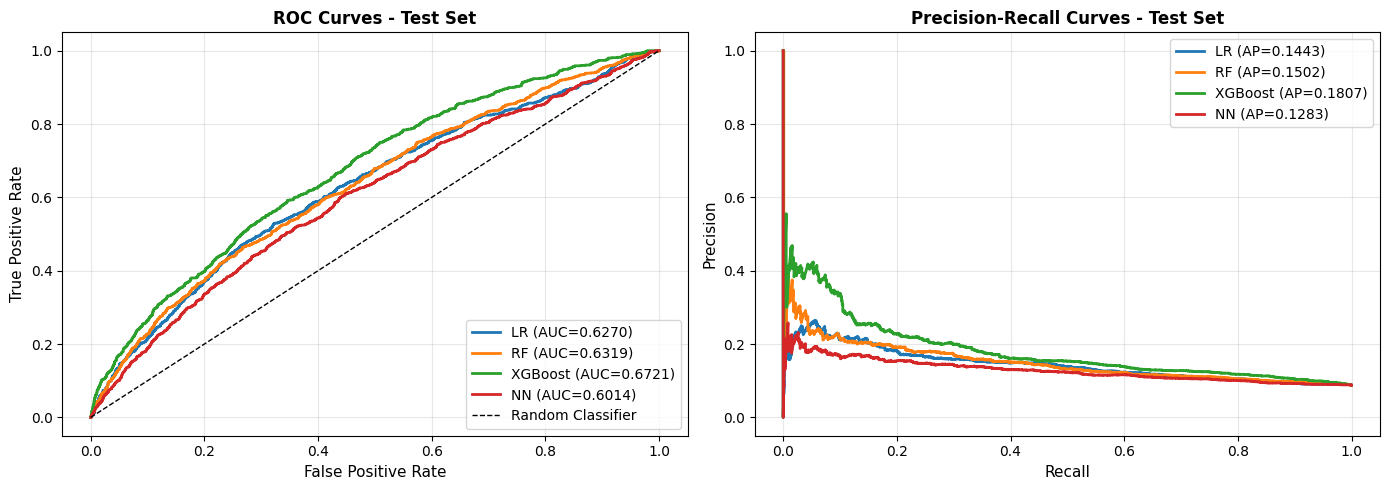

In [9]:
# Visualization: ROC Curves for All Models
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_test_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_test_proba)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_test_proba)
fpr_nn, tpr_nn, _ = roc_curve(y_test, nn_test_proba)

ax1.plot(fpr_lr, tpr_lr, label=f'LR (AUC={lr_test_auc:.4f})', linewidth=2)
ax1.plot(fpr_rf, tpr_rf, label=f'RF (AUC={rf_test_auc:.4f})', linewidth=2)
ax1.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={xgb_test_auc:.4f})', linewidth=2)
ax1.plot(fpr_nn, tpr_nn, label=f'NN (AUC={nn_test_auc:.4f})', linewidth=2)
ax1.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1)
ax1.set_xlabel('False Positive Rate', fontsize=11)
ax1.set_ylabel('True Positive Rate', fontsize=11)
ax1.set_title('ROC Curves - Test Set', fontsize=12, fontweight='bold')
ax1.legend(loc='lower right')
ax1.grid(alpha=0.3)

# Precision-Recall Curves
precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_test_proba)
precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_test_proba)
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_test_proba)
precision_nn, recall_nn, _ = precision_recall_curve(y_test, nn_test_proba)

ax2.plot(recall_lr, precision_lr, label=f'LR (AP={lr_test_ap:.4f})', linewidth=2)
ax2.plot(recall_rf, precision_rf, label=f'RF (AP={rf_test_ap:.4f})', linewidth=2)
ax2.plot(recall_xgb, precision_xgb, label=f'XGBoost (AP={xgb_test_ap:.4f})', linewidth=2)
ax2.plot(recall_nn, precision_nn, label=f'NN (AP={nn_test_ap:.4f})', linewidth=2)
ax2.set_xlabel('Recall', fontsize=11)
ax2.set_ylabel('Precision', fontsize=11)
ax2.set_title('Precision-Recall Curves - Test Set', fontsize=12, fontweight='bold')
ax2.legend(loc='best')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/model_comparison_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ ROC and Precision-Recall curves saved")


Saving trained models...
✓ All models saved


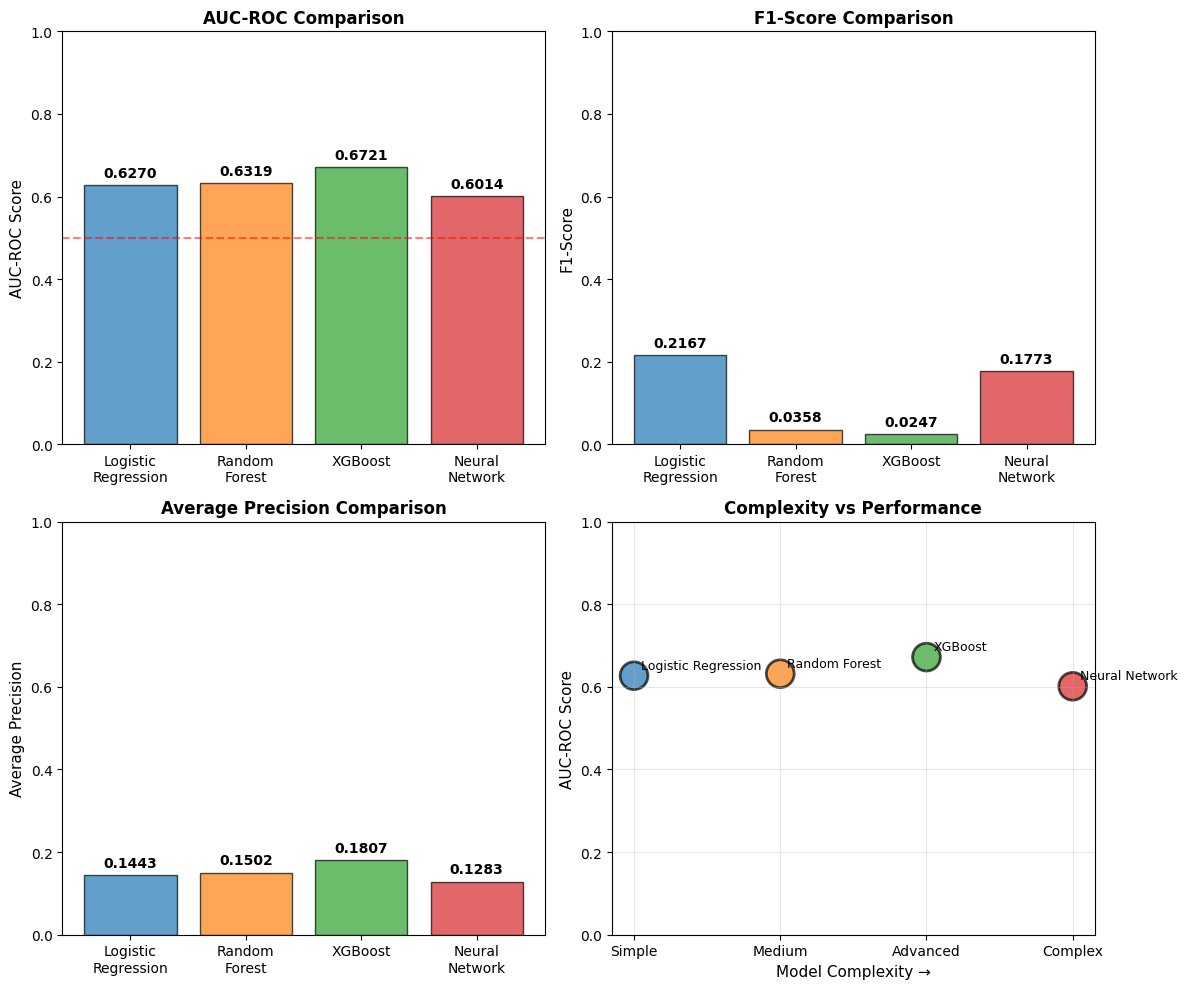

✓ Performance summary visualization saved

RECOMMENDATIONS

✓ Best AUC-ROC: XGBoost (0.6721)
✓ Best F1-Score: Logistic
Regression (0.2167)
✓ Best Avg Precision: XGBoost (0.1807)

Note: Class imbalance (~10:1) makes accuracy misleading.
Focus on AUC-ROC, F1-Score, and Precision-Recall instead.


In [10]:
# Save Models and Create Summary Visualization
import os
import pickle

# Create results directory
os.makedirs('../results', exist_ok=True)

print("\nSaving trained models...")

# Save sklearn models
with open('../results/logistic_regression_model.pkl', 'wb') as f:
    pickle.dump(lr_model, f)

with open('../results/random_forest_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)

with open('../results/xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

# Neural network already saved as best_nn_model.pt
print("✓ All models saved")

# Create comprehensive comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models = ['Logistic\nRegression', 'Random\nForest', 'XGBoost', 'Neural\nNetwork']
auc_scores = [lr_test_auc, rf_test_auc, xgb_test_auc, nn_test_auc]
f1_scores = [lr_test_f1, rf_test_f1, xgb_test_f1, nn_test_f1]
ap_scores = [lr_test_ap, rf_test_ap, xgb_test_ap, nn_test_ap]

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

# AUC-ROC comparison
axes[0, 0].bar(models, auc_scores, color=colors, alpha=0.7, edgecolor='black')
axes[0, 0].set_ylabel('AUC-ROC Score', fontsize=11)
axes[0, 0].set_title('AUC-ROC Comparison', fontsize=12, fontweight='bold')
axes[0, 0].set_ylim([0, 1])
axes[0, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
for i, v in enumerate(auc_scores):
    axes[0, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# F1-Score comparison
axes[0, 1].bar(models, f1_scores, color=colors, alpha=0.7, edgecolor='black')
axes[0, 1].set_ylabel('F1-Score', fontsize=11)
axes[0, 1].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[0, 1].set_ylim([0, 1])
for i, v in enumerate(f1_scores):
    axes[0, 1].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Average Precision comparison
axes[1, 0].bar(models, ap_scores, color=colors, alpha=0.7, edgecolor='black')
axes[1, 0].set_ylabel('Average Precision', fontsize=11)
axes[1, 0].set_title('Average Precision Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_ylim([0, 1])
for i, v in enumerate(ap_scores):
    axes[1, 0].text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

# Model complexity vs performance (AUC-ROC)
complexity = [1, 2, 3, 4]  # 1=LR, 2=RF, 3=XGB, 4=NN
axes[1, 1].scatter(complexity, auc_scores, s=400, c=colors, alpha=0.7, edgecolor='black', linewidth=2)
for i, model in enumerate(models):
    axes[1, 1].annotate(model.replace('\n', ' '), (complexity[i], auc_scores[i]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=9)
axes[1, 1].set_xlabel('Model Complexity →', fontsize=11)
axes[1, 1].set_ylabel('AUC-ROC Score', fontsize=11)
axes[1, 1].set_title('Complexity vs Performance', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(complexity)
axes[1, 1].set_xticklabels(['Simple', 'Medium', 'Advanced', 'Complex'])
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/model_performance_summary.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Performance summary visualization saved")

# Final recommendations
print("\n" + "="*60)
print("RECOMMENDATIONS")
print("="*60)
best_auc_idx = np.argmax(auc_scores)
best_f1_idx = np.argmax(f1_scores)
best_ap_idx = np.argmax(ap_scores)

print(f"\n✓ Best AUC-ROC: {models[best_auc_idx]} ({auc_scores[best_auc_idx]:.4f})")
print(f"✓ Best F1-Score: {models[best_f1_idx]} ({f1_scores[best_f1_idx]:.4f})")
print(f"✓ Best Avg Precision: {models[best_ap_idx]} ({ap_scores[best_ap_idx]:.4f})")
print(f"\nNote: Class imbalance (~10:1) makes accuracy misleading.")
print(f"Focus on AUC-ROC, F1-Score, and Precision-Recall instead.")